# 1. Import 

In [2]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
clr_df = pd.read_csv("../data/processed/06_clr_healthy_data.csv")


# 2. Batch effect

Empirical Bayes methods have proven:
- handle high-dimensional data robustly with small sample sizes
There are also other methods mentioned in the paper. However, the EB method has shown best resulsts and is used until today. It looks across all the samples, not only one, and adjusts the batch effect based on all.

*We also filter out the genes called as “absent” in more than 80% samples to eliminate noise.*

In [11]:
absent_proportion = (clr_df == 0).mean(axis=0)

taxa_to_remove = absent_proportion[absent_proportion > 0.80]
taxa_to_keep = absent_proportion[absent_proportion <= 0.80]

print(f"Total taxa: {clr_df.shape[1]}")
print(f"Taxa absent in >80% of samples: {len(taxa_to_remove)}")
print(f"Taxa remaining after filter: {len(taxa_to_keep)}")


Total taxa: 609
Taxa absent in >80% of samples: 0
Taxa remaining after filter: 609


$$Y_{ijg} = \alpha_{g} + X\beta_{g} + \gamma_{ig} + \delta_{ig}\epsilon_{ijg}$$


* **$Y_{ijg}$** (The Result): The actual measured value for a gene in your data.
* **$\alpha_{g}$** (The Baseline): The normal, starting expression level of the gene.
* **$X\beta_{g}$** (The Biology): The real change caused by your experiment (e.g., drug effect).
* **$\gamma_{ig}$** (The Shift): **Additive noise** that moves all data in a batch up or down.
* **$\delta_{ig}$** (The Volume): **Multiplicative noise** that makes data in a batch more or less "spread out."
* **$\epsilon_{ijg}$** (The Error): Small, random "hiss" or vibration found in every measurement.

### Steps from EB-method


1. Standardizing data, so all samples have similar mean and variance
$$Z_{ijg} = \frac{Y_{ijg} - \hat{\alpha}_{g} - X\hat{\beta}_{g}}{\hat{\sigma}_{g}}$$


2. Estimate Batch effect
- Additive effects: Shift the expression levels up or down
$$Y_{ijg} = \alpha_{g} + X\beta_{g} + \gamma_{ig} + \delta_{ig}\epsilon_{ijg}$$
- Multiplicative effects: Change spread of the data. Bayes part involves using shrinkage. If a sample has outlier results, the method shrinks the result back toward the average of all other genes
$$\delta_{ig}^{2*} = \frac{\theta_{i} + \frac{1}{2} \sum_{j} (Z_{ijg} - \gamma_{ig}^*)^2}{\lambda_{i} + \frac{n_{i}}{2} - 1}$$

3. Adjusting Data: Method takes stable batch effect estimates and applies them to the original data
$$Y_{ijg}^* = \frac{\hat{\sigma}_{g}}{\delta_{ig}^*}(Z_{ijg} - \gamma_{ig}^*) + \hat{\alpha}_{g} + X\hat{\beta}_{g}$$


* **$Y_{ijg}^*$** (Adjusted Result): The clean, final data point with batch effects removed.
* **$\hat{\sigma}_{g}$** (Biological Standard Deviation): The "natural" variation of the gene we want to keep.
* **$\delta_{ig}^*$** (Batch Scale): The estimated "volume" or noise spread of the specific batch.
* **$Z_{ijg}$** (Standardized Data): The "leveled" data from Step 1.
* **$\gamma_{ig}^*$** (Batch Shift): The estimated "additive" shift (up or down) of the specific batch.
* **$\hat{\alpha}_{g}$** (Baseline): The gene's average starting expression level.
* **$X\hat{\beta}_{g}$** (Biological Signal): The real experimental effect (e.g., treatment effect) we want to preserve.





### Difficulties

The problem in this PA is, that the interest lies in the country differences, which are also "batch differences". This makes it difficult to correct the batch effect without losing valuable informations. 

If done PCA: Clusters could explain real biological differences between countries OR technical differences

## 2.1 PCA

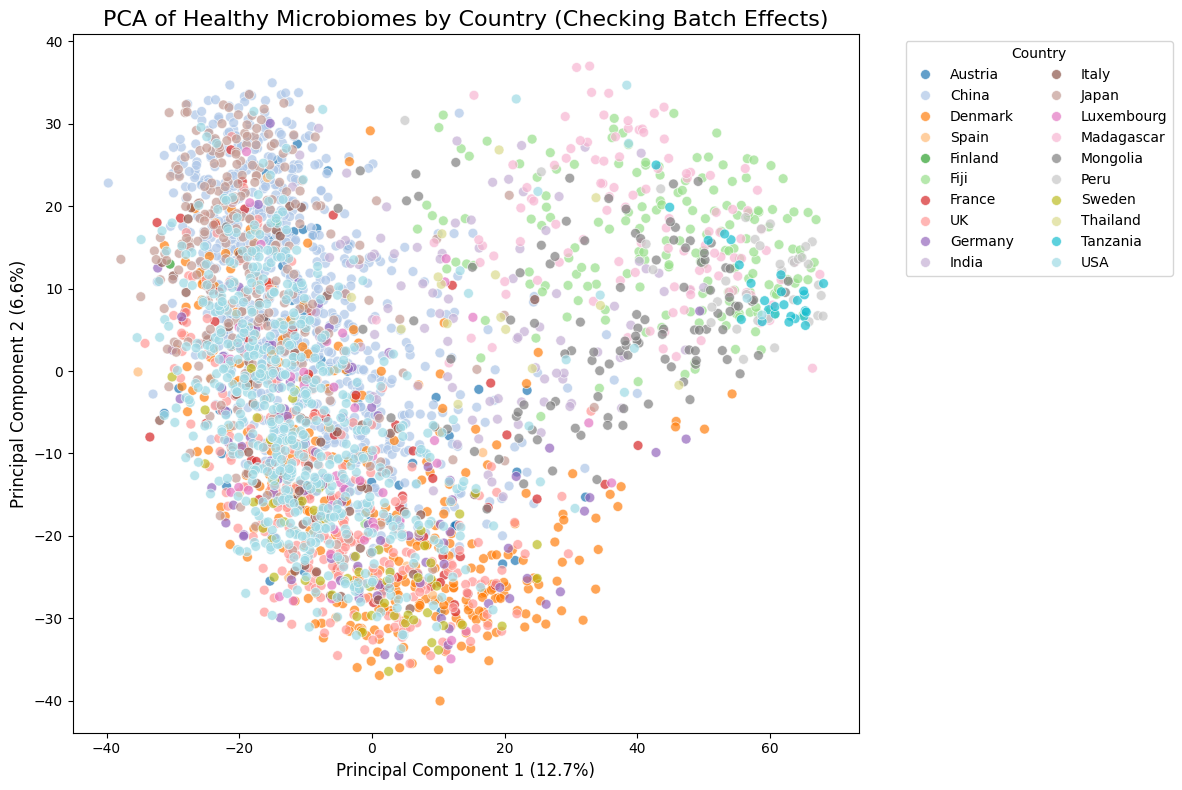

In [ ]:

# --- 2. Separate Features (Microbiome) and Labels (Country) ---
# Automatically find all the microbiome columns (they all start with "msp_")
microbiome_cols = [col for col in clr_df.columns if col.startswith('msp_')]


X = clr_df[microbiome_cols]
y = clr_df['Geography']

# Run PCA 
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Create a new DataFrame specifically for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Country'] = y.values

# Calculate how much variance is explained by the first two components
explained_variance = pca.explained_variance_ratio_ * 100

# --- 4. Plot the Results ---
plt.figure(figsize=(12, 8))

# Scatter plot coloring the dots by Country
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Country', 
    palette='tab20', # 'tab20' handles up to 20 colors. 
    data=pca_df, 
    alpha=0.7,       # slight transparency
    s=50             # dot size
)

# Add titles and labels
plt.title('PCA of Healthy Microbiomes by Country (Checking Batch Effects)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1f}%)', fontsize=12)

# Move the legend outside the plot so it doesn't cover your dots
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Country', ncol=2)
plt.tight_layout()

# Show the plot
plt.show()

1. Are those dots sitting all the way over there because the diet in Tanzania creates a truly unique biological microbiome? (Geography)

2. Are those dots sitting over there because the lab handling BioProject PRJNA278393 left their samples in the fridge too long, or used a different DNA sequencing machine, completely changing the data? (Batch Effect)

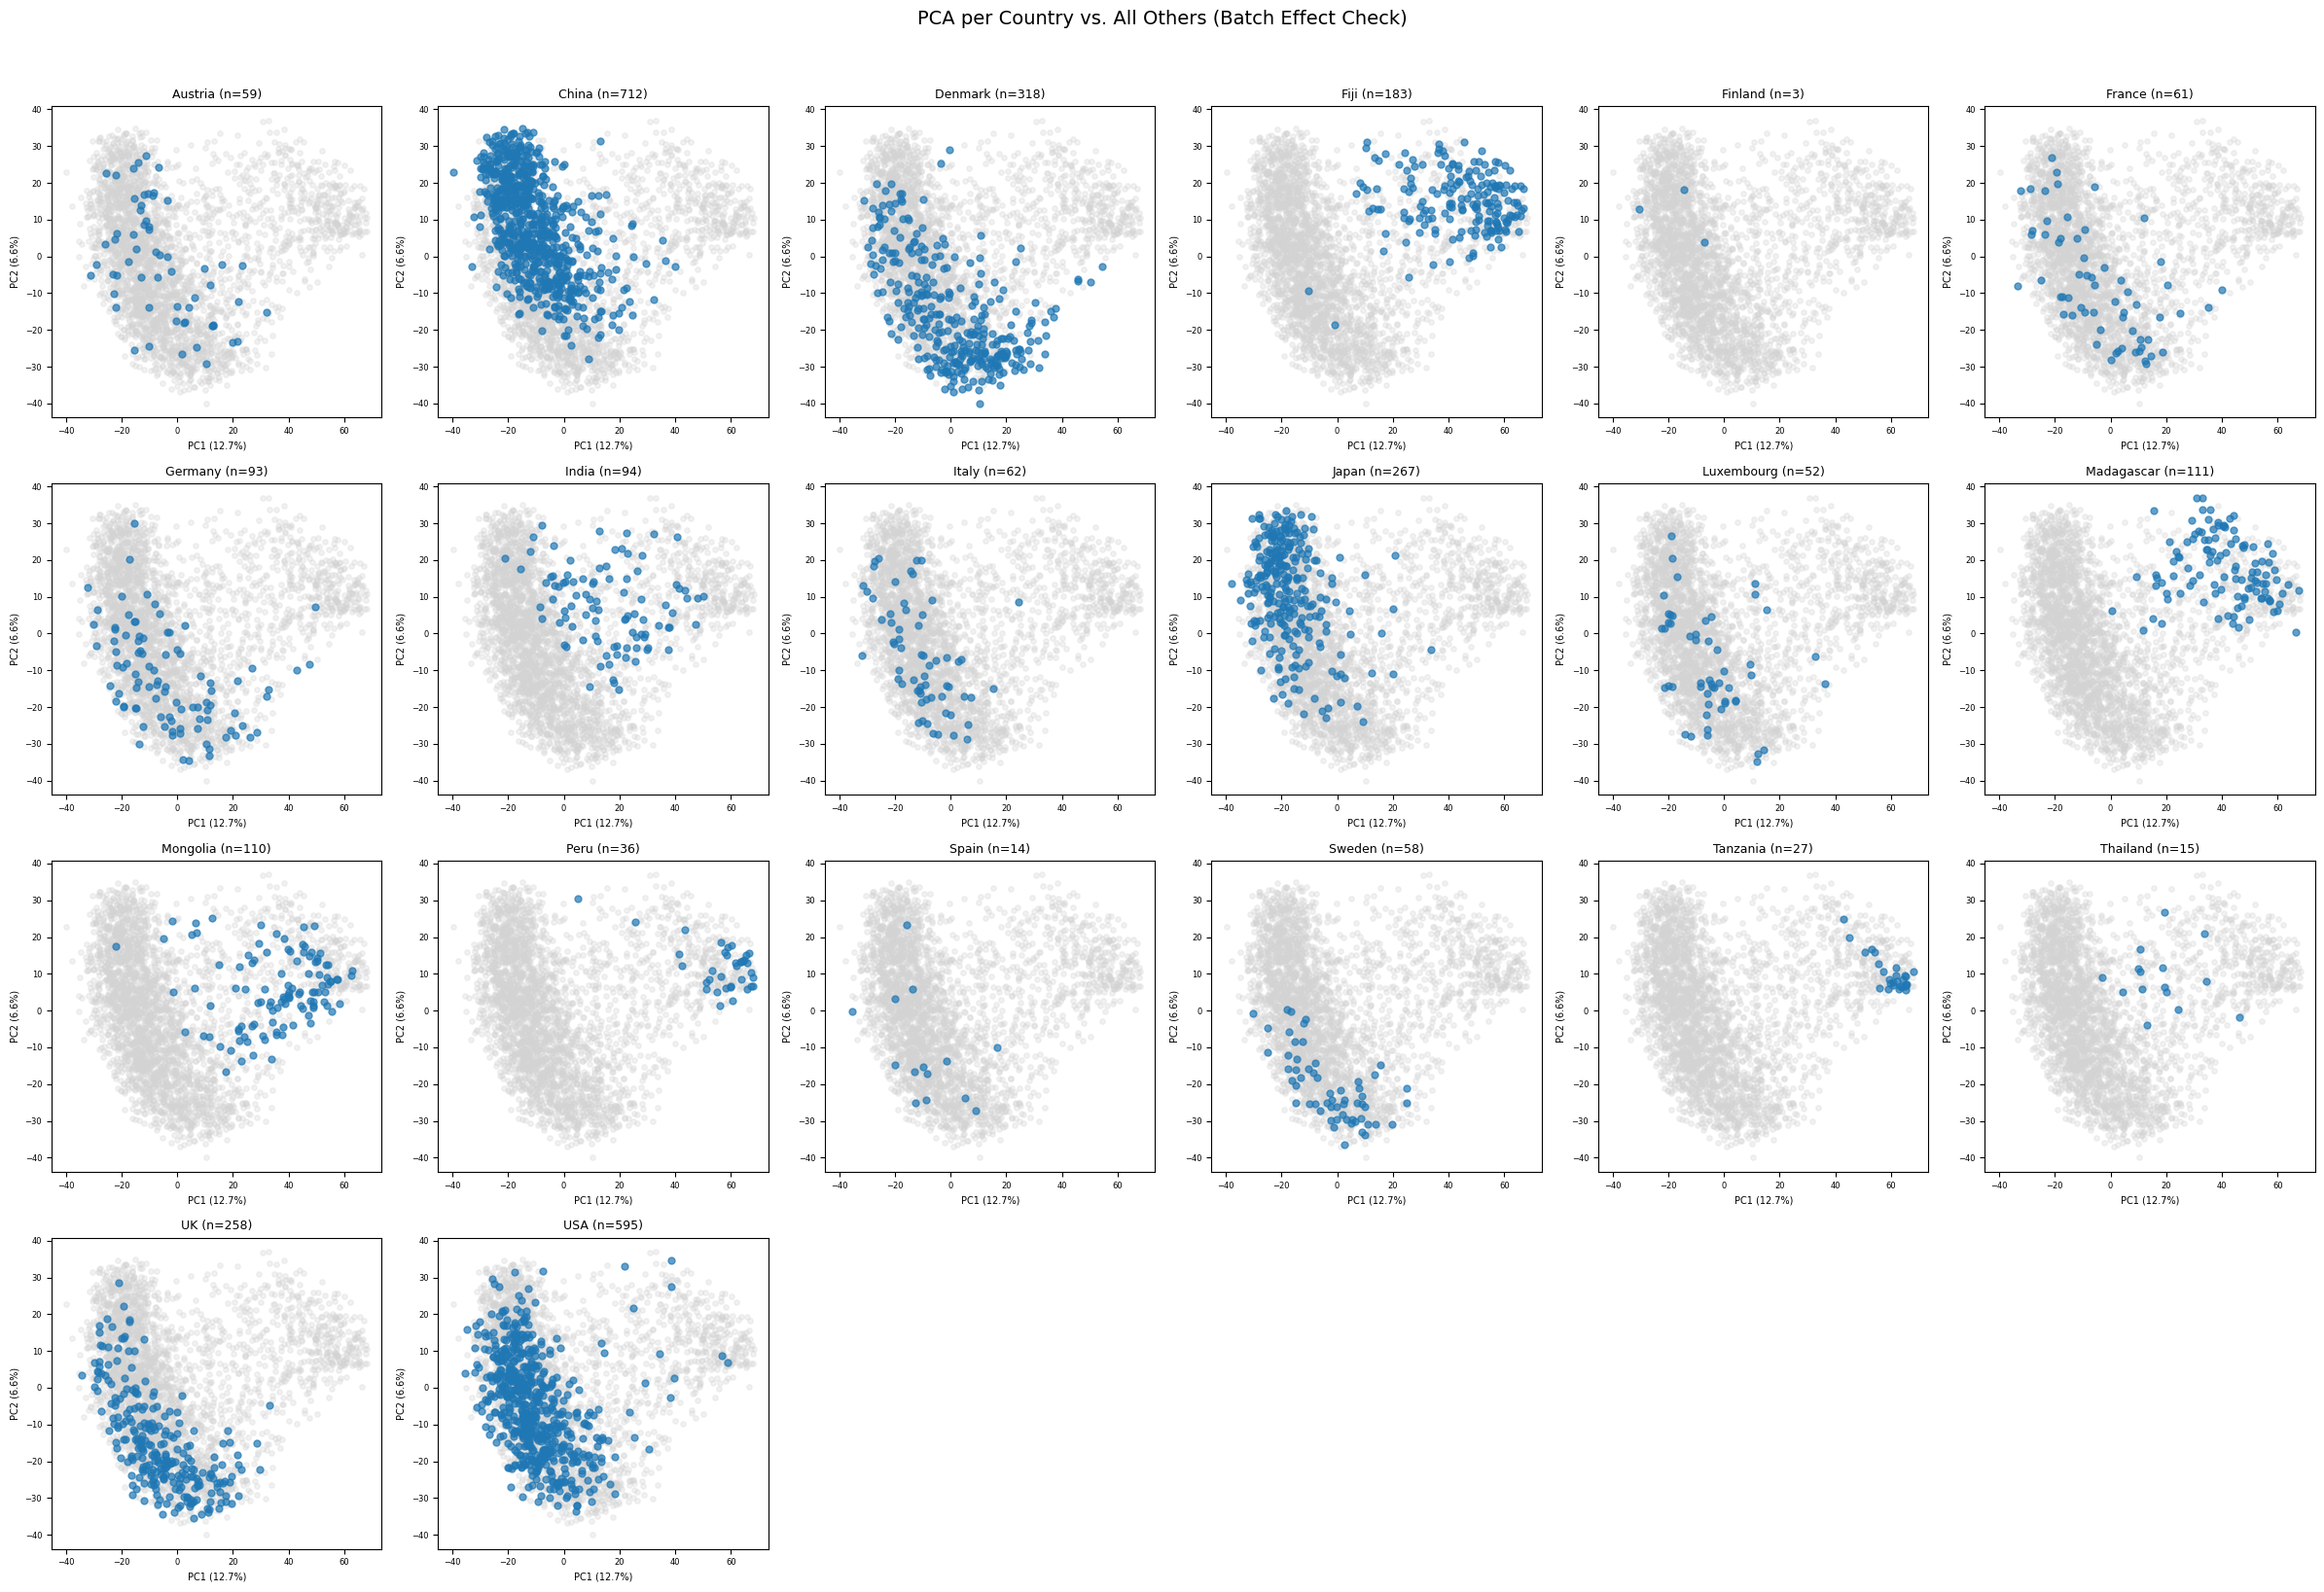

In [15]:
import math

# --- PCA per Country ---
countries = pca_df['Country'].unique()
n_countries = len(countries)

# Calculate grid size
n_cols = 6
n_rows = math.ceil(n_countries / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, country in enumerate(sorted(countries)):
    ax = axes[i]
    
    # All other countries as grey background for reference
    other = pca_df[pca_df['Country'] != country]
    ax.scatter(other['PC1'], other['PC2'], c='lightgrey', alpha=0.3, s=15, label='Other')
    
    # Highlight the current country
    subset = pca_df[pca_df['Country'] == country]
    ax.scatter(subset['PC1'], subset['PC2'], alpha=0.7, s=25, label=country)
    
    ax.set_title(f'{country} (n={len(subset)})', fontsize=9)
    ax.set_xlabel(f'PC1 ({explained_variance[0]:.1f}%)', fontsize=7)
    ax.set_ylabel(f'PC2 ({explained_variance[1]:.1f}%)', fontsize=7)
    ax.tick_params(labelsize=6)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('PCA per Country vs. All Others (Batch Effect Check)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Countries with multiple BioProjects: ['China', 'Denmark', 'Germany', 'Italy', 'Sweden', 'UK', 'USA']


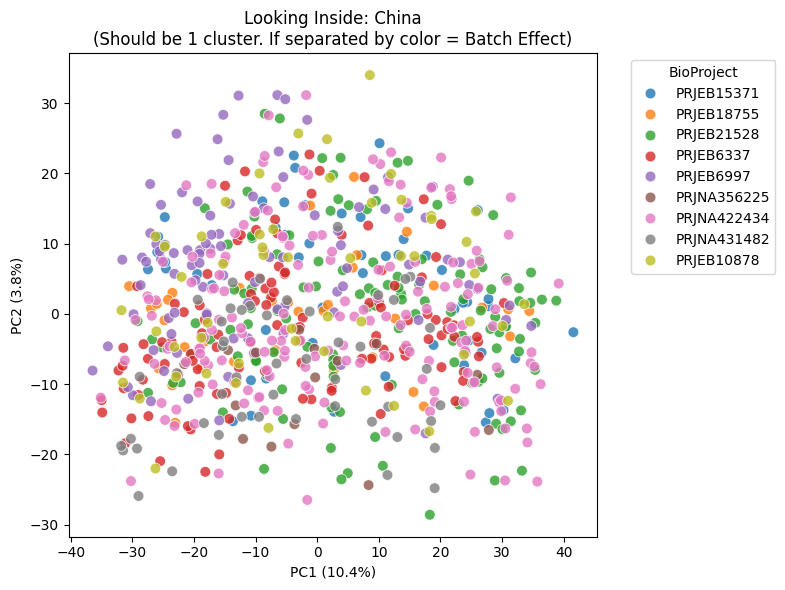

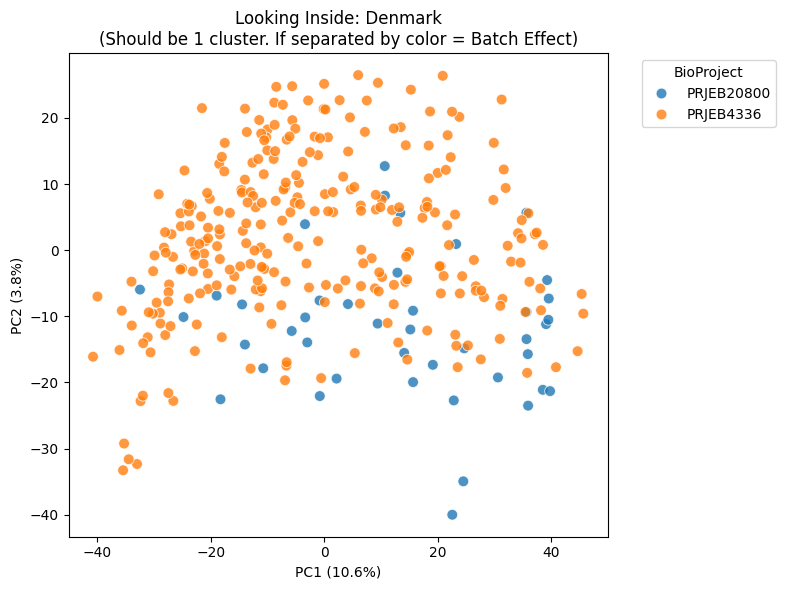

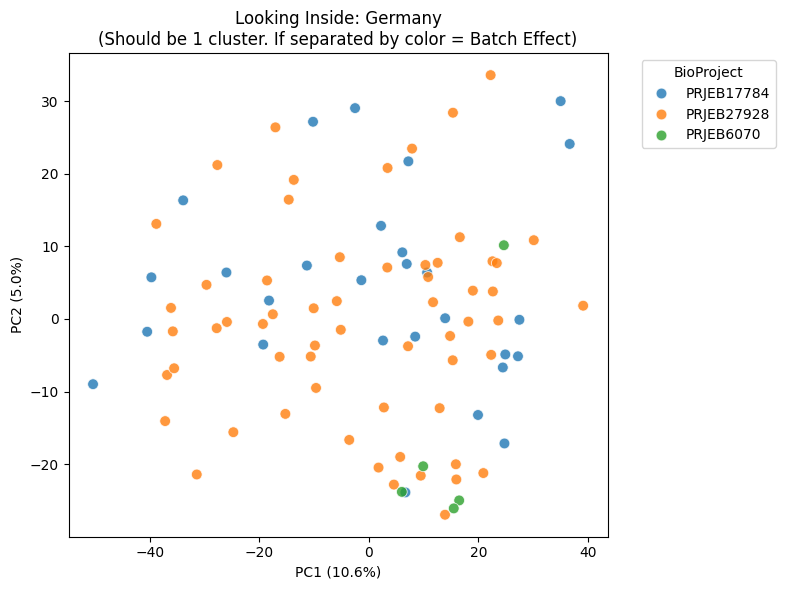

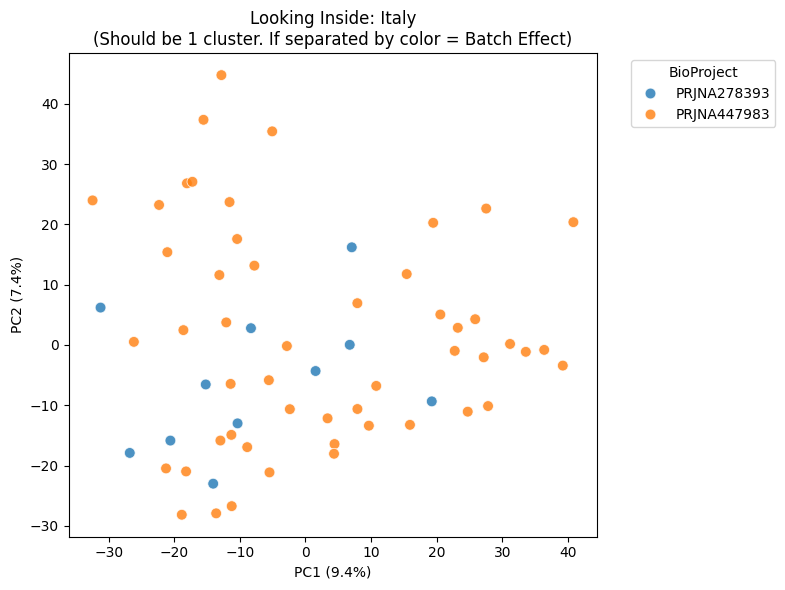

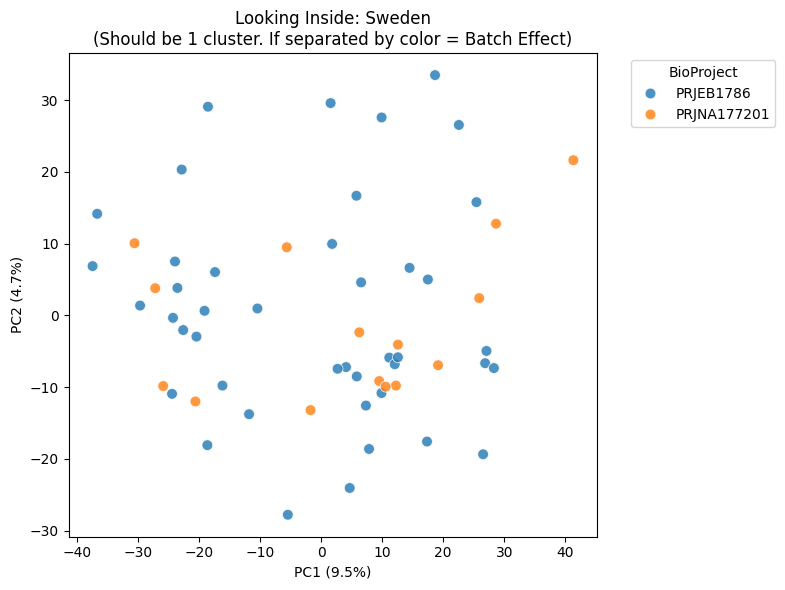

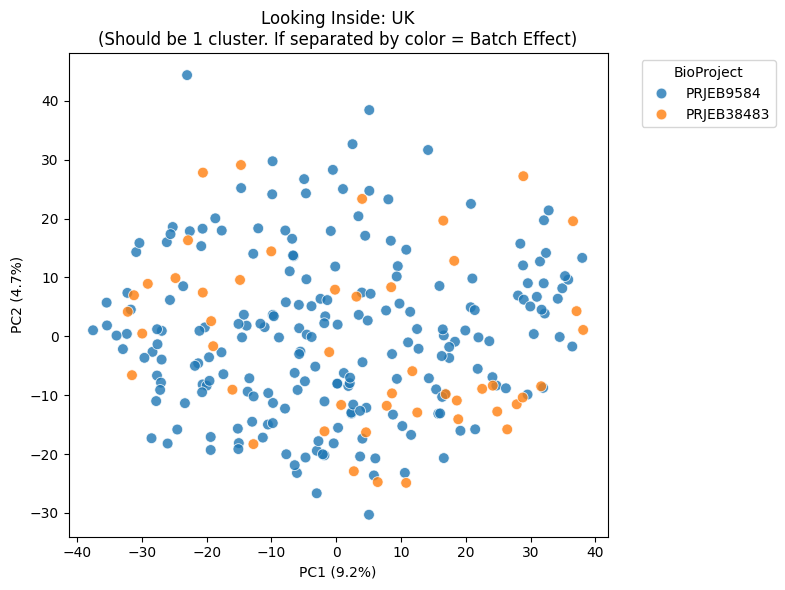

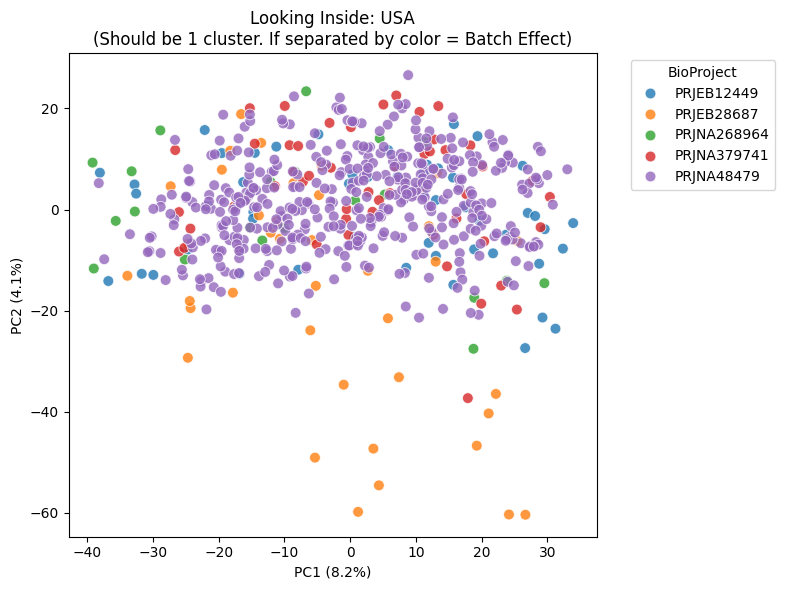

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# --- 1. Load Data & Separate Features ---
clr_df = pd.read_csv("../data/processed/06_clr_healthy_data.csv")
microbiome_cols = [col for col in clr_df.columns if col.startswith('msp_')]

# --- 2. Find countries with multiple BioProjects ---
# This counts how many unique BioProjects exist for each Country
project_counts = clr_df.groupby('Geography')['BioProject'].nunique()

# Keep only the countries that have MORE THAN ONE BioProject
multi_batch_countries = project_counts[project_counts > 1].index.tolist()

print(f"Countries with multiple BioProjects: {multi_batch_countries}")

# --- 3. Plot a PCA for each of these specific countries ---
if not multi_batch_countries:
    print("No countries in your dataset belong to multiple BioProjects. Perfect confounding!")
else:
    for country in multi_batch_countries:
        # Filter data for ONLY this country
        country_df = clr_df[clr_df['Geography'] == country]
        X_country = country_df[microbiome_cols]
        y_batch = country_df['BioProject']
        
        # Run PCA on just this country's data
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(X_country)
        explained_var = pca.explained_variance_ratio_ * 100
        
        # Create a plotting dataframe
        plot_df = pd.DataFrame(data=pcs, columns=['PC1', 'PC2'])
        plot_df['BioProject'] = y_batch.values
        
        # Plot
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=plot_df, 
            x='PC1', 
            y='PC2', 
            hue='BioProject', 
            palette='tab10', 
            s=60, 
            alpha=0.8
        )
        
        plt.title(f"Looking Inside: {country}\n(Should be 1 cluster. If separated by color = Batch Effect)")
        plt.xlabel(f"PC1 ({explained_var[0]:.1f}%)")
        plt.ylabel(f"PC2 ({explained_var[1]:.1f}%)")
        plt.legend(title='BioProject', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# 3. Depth effect